### Import Libraries

In [1]:
import pandas as pd
import numpy as np

### Read the processed India crop yield data

In [2]:
data = pd.read_csv('../data/processed/Processed_India_Crop_Yield_Data.csv')

# Display basic info
data.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,kg_per_ha_yield
0,10502,India,Cassava,1990,205381,1083.0,75000.0,25.58,20538.1
1,10503,India,Cassava,1990,205381,1083.0,75000.0,26.88,20538.1
2,10504,India,Cassava,1990,205381,1083.0,75000.0,25.79,20538.1
3,10505,India,Cassava,1990,205381,1083.0,75000.0,24.10,20538.1
4,10506,India,Cassava,1990,205381,1083.0,75000.0,25.25,20538.1


### Feature Engineering for Temperate - Rainfall Interaction

In [3]:
data['temp_rainfall_interaction'] = data['avg_temp'] * data['average_rain_fall_mm_per_year']

### Avg Rainfall in mm per year

In [6]:
mean_rainfall = data['average_rain_fall_mm_per_year'].mean()

# Create deviation feature
data['rainfall_deviation'] = data['average_rain_fall_mm_per_year'] - mean_rainfall

### Rainfall Squared

In [7]:
data['rainfall_squared'] = data['average_rain_fall_mm_per_year'] ** 2

### Temperature Sqaured

In [8]:
data['temp_squared'] = data['avg_temp'] ** 2

### Pesticides Per Rainfall

In [9]:
data['pesticide_per_rainfall'] = data['pesticides_tonnes'] / (data['average_rain_fall_mm_per_year'] + 1)

In [10]:
# Ensure year is numeric
data['Year'] = pd.to_numeric(data['Year'], errors='coerce')

### Newly engineered features preview

In [13]:
print("Newly engineered features preview:")
data[['temp_rainfall_interaction', 'rainfall_deviation', 'rainfall_squared', 'temp_squared', 'pesticide_per_rainfall']].head()

Newly engineered features preview:


,temp_rainfall_interaction,rainfall_deviation,rainfall_squared,temp_squared,pesticide_per_rainfall
0,27703.14,0.0,1172889.0,654.3364,69.188192
1,29111.04,0.0,1172889.0,722.5344,69.188192
2,27930.57,0.0,1172889.0,665.1241,69.188192
3,26100.30,0.0,1172889.0,580.8100,69.188192
4,27345.75,0.0,1172889.0,637.5625,69.188192


In [14]:
# Save for your model training pipeline
data.to_csv('../data/processed/Feature_Engineered_Crop_Yield_Data.csv', index=False)

print("Feature engineered dataset saved as 'Feature_Engineered_Crop_Yield_Data.csv'")
data.head()

Feature engineered dataset saved as 'Feature_Engineered_Crop_Yield_Data.csv'


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,kg_per_ha_yield,temp_rainfall_interaction,rainfall_deviation,rainfall_squared,temp_squared,pesticide_per_rainfall
0,10502,India,Cassava,1990,205381,1083.0,75000.0,25.58,20538.1,27703.14,0.0,1172889.0,654.3364,69.188192
1,10503,India,Cassava,1990,205381,1083.0,75000.0,26.88,20538.1,29111.04,0.0,1172889.0,722.5344,69.188192
2,10504,India,Cassava,1990,205381,1083.0,75000.0,25.79,20538.1,27930.57,0.0,1172889.0,665.1241,69.188192
3,10505,India,Cassava,1990,205381,1083.0,75000.0,24.10,20538.1,26100.30,0.0,1172889.0,580.8100,69.188192
4,10506,India,Cassava,1990,205381,1083.0,75000.0,25.25,20538.1,27345.75,0.0,1172889.0,637.5625,69.188192


### Define new feature set for model

In [15]:
X = data[['average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes',
          'temp_rainfall_interaction', 'rainfall_deviation', 'rainfall_squared',
          'temp_squared', 'pesticide_per_rainfall']]

y = data['hg/ha_yield']

### Import required Libraries for training and testing

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

### Define features and target

In [21]:
# Load your feature engineered dataset
data = pd.read_csv('../data/processed/Feature_Engineered_Crop_Yield_Data.csv')

X = data[[ 'avg_temp', 'pesticides_tonnes',
          'temp_rainfall_interaction',
          'temp_squared', 'pesticide_per_rainfall']]

y = data['kg_per_ha_yield']

### Initialize and train model

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Extracting feature importances

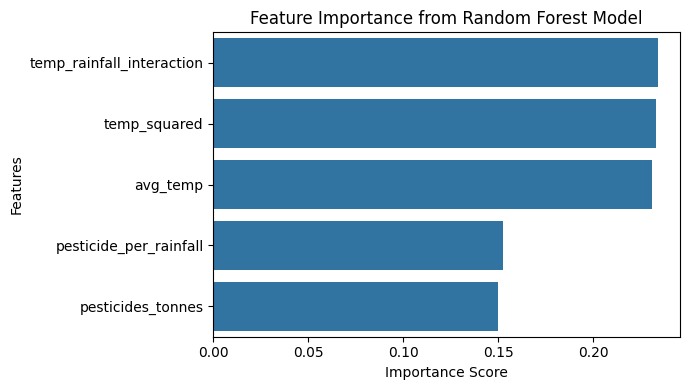

In [24]:
importances = rf_model.feature_importances_

# Create a dataframe for plotting
feat_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance
feat_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(7,4))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df)
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()